In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.integrate as scp
from scipy.linalg import eigh
from scipy.optimize import brentq


parameters 

In [2]:

#environment parameters
rho_w = 1025 # [kg/m3]
g = 9.81 # [m/s2]
rho_air = 1.225 # [kg/m3]

#wave parameters
H_wave = 6.0 #[m]
T_wave = 10.0 #[s]
d_water = 320 #[m]
omega_w = 2 * np.pi / T_wave # [rad/s]
zeta_w = H_wave / 2 # [m]



#morison coefficients 
C_D = 1.0  #drag coefficient
C_M = 2.0 #inertia coefficient
C_a = C_M - 1.0 #added mass coefficient

#current 
U_c = 0.5  #m/s 

#wind
U_wind = 10.59 #[m/s]
C_T = 0.799 
D_rotor = 126 #[m]

A_rotor = np.pi * (D_rotor / 2)**2  # [m2]
F_thrust = 0.5 * rho_air * U_wind**2 * A_rotor * C_T  # [N]
 
print(f"Thrust force on rotor: {F_thrust:.2f} N")




# tower
E_tower = 210e9 # [N/m2]
rho_eff_tower = 8500 # [kg/m3]
z_base = 10 # [m]
z_top = 87.6 # [m]
L_tower = z_top - z_base # [m]
D_base = 6.5 # [m]
D_top = 3.87 # [m]
t_base = 0.027 # [m]
t_top = 0.019 # [m]


# RNA
m_RNA = 350000             # [kg]


#spar 
m_spar = 7466330                # [kg]
CoG_z = -89.92
I_pitch = 4229230000                 # [kg.m2]
draft = 120 
D_above = 6.5
D_below = 9.4 
z_tap_t = -4.0 
z_tap_b = -12 

#vertical distance from spar CoG to tower base
h_CoG_to_base = z_base - CoG_z
print(f"Vertical distance from spar CoG to tower base: {h_CoG_to_base:.2f} m")

#hydrostatic restoring 

A_wp = np.pi * (D_above)**2  / 4  # [m2]
K_heave_hs = rho_w * g * A_wp  # [N/m]

GM = 1
V_spar = m_spar / rho_w # [m3]
K_pitch_hs = rho_w * g * V_spar * GM  # [N.m/rad]


print(f"Hydrostatic stiffness in heave: {K_heave_hs:.2f} N/m")
print(f"Hydrostatic stiffness in pitch: {K_pitch_hs:.2f} N.m/rad")


#mooring 
K_surge_moor= 88815.83 # [N/m]
K_heave_moor = 0 # [N/m]
K_pitch_moor = 0 # [N.m/rad]





Thrust force on rotor: 684346.05 N
Vertical distance from spar CoG to tower base: 99.92 m
Hydrostatic stiffness in heave: 333664.09 N/m
Hydrostatic stiffness in pitch: 73244697.30 N.m/rad


In [3]:
#wave number 

def dispersion(k, omega, d): 
    return omega**2 - g * k * np.tanh(k * d)

k_wave = brentq(dispersion, 0.01, 10, args=(omega_w, d_water))
lam = 2* np.pi / k_wave

print(f"Wave number: {k_wave:.4f} rad/m")
print(f"Wavelength: {lam:.2f} m")
print(f"D/lambda: {D_above / lam:.4f}")

Wave number: 0.0402 rad/m
Wavelength: 156.13 m
D/lambda: 0.0416


D/lambda <<< 1 so we can apply morison 

Discretization

In [4]:
# Define node coordinates
 
n_elem = 40 
n_nodes = n_elem + 1

le = L_tower / n_elem

nodes_z = np.linspace(z_base, z_top, n_nodes)

NodeCoord = np.column_stack([np.zeros(n_nodes), nodes_z])

print(f"number of nodes {n_nodes}")
print(f"Element length: {le:.2f} m")
print(f"Node elevations: {nodes_z}")

number of nodes 41
Element length: 1.94 m
Node elevations: [10.   11.94 13.88 15.82 17.76 19.7  21.64 23.58 25.52 27.46 29.4  31.34
 33.28 35.22 37.16 39.1  41.04 42.98 44.92 46.86 48.8  50.74 52.68 54.62
 56.56 58.5  60.44 62.38 64.32 66.26 68.2  70.14 72.08 74.02 75.96 77.9
 79.84 81.78 83.72 85.66 87.6 ]


EA and EI:

In [5]:
D_mean = (D_base + D_top) / 2
t_mean = (t_base + t_top) / 2

r_o = D_mean / 2
r_i = r_o - t_mean
A_tower = np.pi * (r_o**2 - r_i**2)  # [m2]
I_tower = np.pi * (r_o**4 - r_i**4) / 4  # [m4]

EA_tower = E_tower * A_tower  # [N]
EI_tower = E_tower * I_tower  # [N.m2]
rhoA_tower = rho_eff_tower * A_tower  # [kg/m]

print(f"D_mean: {D_mean:.2f} m, t_mean: {t_mean:.3f} m")
print(f"A = {A_tower:.4f} m2, I = {I_tower:.6f} m4")
print(f"EA = {EA_tower:.2f} N, EI = {EI_tower:.2f} N.m2")
print(f"rhoA = {rhoA_tower:.2f} kg/m")


D_mean: 5.19 m, t_mean: 0.023 m
A = 0.3730 m2, I = 1.242368 m4
EA = 78327633171.92 N, EI = 260897332594.93 N.m2
rhoA = 3170.40 kg/m


Matrices: 

In [6]:
def element_matrices(le): 

    #axial
    Ka = (EA_tower / le) * np.array([[1, -1], [-1, 1]])
    Ma = (rhoA_tower * le / 6) * np.array([[2, 1], [1, 2]])

    #bending 
    Kb = (EI_tower / le**3) * np.array([[   12,    6*le,   -12,    6*le], 
                                         [6*le, 4*le**2, -6*le, 2*le**2], 
                                         [-12,    -6*le,    12,   -6*le], 
                                         [6*le, 2*le**2, -6*le, 4*le**2]])

    Mb = (rhoA_tower * le / 420) * np.array([[156,        22*le,     54,   -13*le],
                                             [22*le,    4*le**2,  13*le, -3*le**2],
                                             [54,         13*le,    156,  -22*le],  
                                             [-13*le,  -3*le**2, -22*le, 4*le**2]])
    
    Ke = np.zeros((6, 6))
    Me = np.zeros((6, 6))
    axial_dof = [0, 3]
    bending_dof = [1, 2, 4, 5]
    Ke[np.ix_(axial_dof, axial_dof)] = Ka
    Ke[np.ix_(bending_dof, bending_dof)] = Kb
    Me[np.ix_(axial_dof, axial_dof)] = Ma
    Me[np.ix_(bending_dof, bending_dof)] = Mb

    return Me, Ke

each element connects 2 nodes; each node has 3 dof so we have 6 dof in total u_1, w_1, teta_1, u2, w2, teta_2"

In [7]:
#CHECK

Me_test, Ke_test = element_matrices(le)
print("Me (6×6):")
print(np.round(Me_test, 2))
print("\nKe (6×6):")
print(np.round(Ke_test, 2))

Me (6×6):
[[2050.19    0.      0.   1025.1     0.      0.  ]
 [   0.   2284.5   625.02    0.    790.79 -369.33]
 [   0.    625.02  220.46    0.    369.33 -165.35]
 [1025.1     0.      0.   2050.19    0.      0.  ]
 [   0.    790.79  369.33    0.   2284.5  -625.02]
 [   0.   -369.33 -165.35    0.   -625.02  220.46]]

Ke (6×6):
[[ 4.03750686e+10  0.00000000e+00  0.00000000e+00 -4.03750686e+10
   0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  4.28791033e+11  4.15927302e+11  0.00000000e+00
  -4.28791033e+11  4.15927302e+11]
 [ 0.00000000e+00  4.15927302e+11  5.37932645e+11  0.00000000e+00
  -4.15927302e+11  2.68966322e+11]
 [-4.03750686e+10  0.00000000e+00  0.00000000e+00  4.03750686e+10
   0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00 -4.28791033e+11 -4.15927302e+11  0.00000000e+00
   4.28791033e+11 -4.15927302e+11]
 [ 0.00000000e+00  4.15927302e+11  2.68966322e+11  0.00000000e+00
  -4.15927302e+11  5.37932645e+11]]


Global assembly: 

Global mass matrix M_g size: 126 x 126
floater mass on diagonal: 7.466e+06 kg
RNA mass on diagonal: 3.521e+05 kg


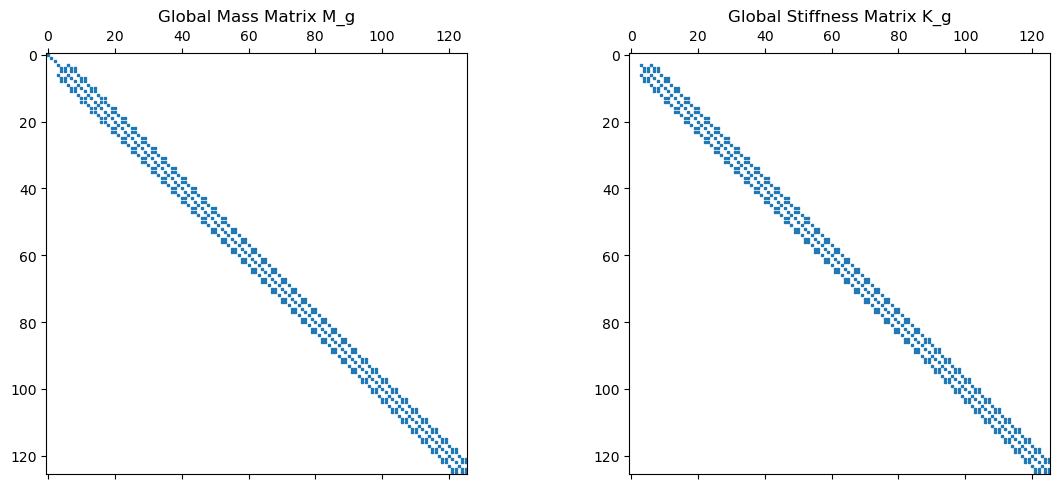

In [8]:
n_dof = 3 + 3 * n_nodes  #3 from the spar + 3 per node from the tower

M_g = np.zeros((n_dof, n_dof))
K_g = np.zeros((n_dof, n_dof))

for iElem in range(n_elem):
    nl = iElem #left node index
    nR = iElem + 1 #right node index
   

    Me, Ke = element_matrices(le)

    dofs = np.array([ 3+ 3*nl , 3 + 3*nl + 1, 3 + 3*nl + 2, 3 + 3*nR, 3 + 3*nR + 1, 3 + 3*nR + 2])
    
    for i in range(6): 
        for j in range(6):
            M_g[dofs[i], dofs[j]] += Me[i, j]
            K_g[dofs[i], dofs[j]] += Ke[i, j]

M_g[0,0] += m_spar
M_g[1,1] += m_spar
M_g[2,2] += I_pitch

top_dofs = [3 + 3*n_elem, 3 + 3*n_elem + 1, 3 + 3*n_elem+2]
M_g[top_dofs[0], top_dofs[0]] += m_RNA
M_g[top_dofs[1], top_dofs[1]] += m_RNA
#no rotational inertia

print(f"Global mass matrix M_g size: {n_dof} x {n_dof}")
print(f"floater mass on diagonal: {M_g[0,0]:.3e} kg")
print(f"RNA mass on diagonal: {M_g[top_dofs[0], top_dofs[0]]:.3e} kg")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].spy(M_g, markersize=2)
axes[0].set_title("Global Mass Matrix M_g")
axes[1].spy(K_g, markersize=2)
axes[1].set_title("Global Stiffness Matrix K_g")
plt.tight_layout()
plt.show()

T_link 
emilnae the tower base 

Reduced system size: 123 x 123
T_link (h = 99.92 m):
[[ 1.    0.   99.92]
 [ 0.    1.    0.  ]
 [ 0.    0.    1.  ]]


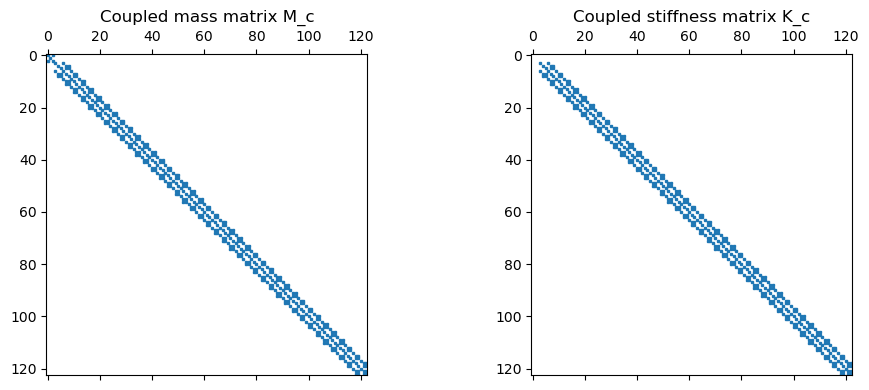

In [9]:
def build_T_link(h): 
    return np.array([[1, 0, h], [0, 1, 0], [0, 0, 1]])

def apply_kinematic_coupling(M_g, K_g, n_dof): 

    n_red = n_dof - 3
    T_link = build_T_link(h_CoG_to_base)

    T_full = np.zeros((n_dof, n_red))

    T_full[0:3, 0:3] = T_link
    T_full[6:, 3:] = np.eye(n_dof - 6)

    M_c = T_full.T @ M_g @ T_full 
    K_c = T_full.T @ K_g @ T_full

    return M_c, K_c, T_full, n_red 

M_c, K_c, T_full, n_red = apply_kinematic_coupling(M_g, K_g, n_dof)

print(f"Reduced system size: {n_red} x {n_red}")
print(f"T_link (h = {h_CoG_to_base:.2f} m):")
print(np.round(build_T_link(h_CoG_to_base),3 ))

fig, axes = plt.subplots (1,2, figsize= (10,4)) 
axes[0].spy(M_c, markersize = 2) 
axes[0].set_title("Coupled mass matrix M_c")
axes[1].spy(K_c, markersize=2)
axes[1].set_title("Coupled stiffness matrix K_c")
plt.tight_layout()
plt.show()

when the spar accelerate through water, it drags some water with it 

In [10]:
#added mass (hydrodynamic)

V_spar = m_spar / rho_w
M_added = C_a * rho_w * V_spar
M_c[0,0] += M_added
M_c[1,1] += M_added

print(f"displaced volume V_spar = {V_spar:.1f} m^3")
print(f"Aded mass M_added = {M_added:.3e} kg")
print(f"M_c[0,0] after added mass: {M_c[0,0]:.3e} kg")


displaced volume V_spar = 7284.2 m^3
Aded mass M_added = 7.466e+06 kg
M_c[0,0] after added mass: 1.493e+07 kg


In [11]:
#hydrostatic and mooring stiffness

K_c[0,0] += K_surge_moor
K_c[1,1] += K_heave_hs + K_heave_moor 
K_c[2,2] += K_pitch_hs + K_pitch_moor

print(f"K_heave (hydrostatic) = {K_heave_hs:.3e} N/m")
print(f"K_pitch (hydrostatic) = {K_pitch_hs:.3e} N.m / rad")
print(f"K_surge (mooring) = {K_surge_moor:.3e} N/m")
print(f"K_c[0,0] surge: {K_c[0,0]:.3e}")
print(f"K_c[1,1] heave: {K_c[1,1]:.3e}")
print(f"K_c[2,2] pitch: {K_c[2,2]:.3e}")

K_heave (hydrostatic) = 3.337e+05 N/m
K_pitch (hydrostatic) = 7.324e+07 N.m / rad
K_surge (mooring) = 8.882e+04 N/m
K_c[0,0] surge: 8.882e+04
K_c[1,1] heave: 3.337e+05
K_c[2,2] pitch: 7.324e+07


Modal analysis: 

In [12]:

eigenvalues, eigenvectors = eigh(K_c, M_c)

# Natural frequencies
omega_n = np.sqrt(np.abs(eigenvalues)) #rad/s
f_n = omega_n / (2 * np.pi) #Hz
T_n = 1 / f_n  #s

print("First 6 natural frequencies [Hz]:")
print(f"{'Mode':<6}{'omega [rad/s]' :<16} {'f [Hz]':<12} {'T[s]'}")
for i in range(6):
    print(f"{i+1:<6} {omega_n[i] : <16.4f} {f_n[i]:< 12.4f}{T_n[i]:.3f}")




First 6 natural frequencies [Hz]:
Mode  omega [rad/s]    f [Hz]       T[s]
1      0.0293            0.0047     214.145
2      0.1104            0.0176     56.901
3      0.1495            0.0238     42.033
4      2.0256            0.3224     3.102
5      24.1405           3.8421     0.260
6      48.1556           7.6642     0.130


pitch at 18s is a bit low (OC3 says 28s) but may be the simplification of GM = 1

in the reduced system: floater = DOFs 0,1,2 and tower node 0 is DOFs 3,4,5

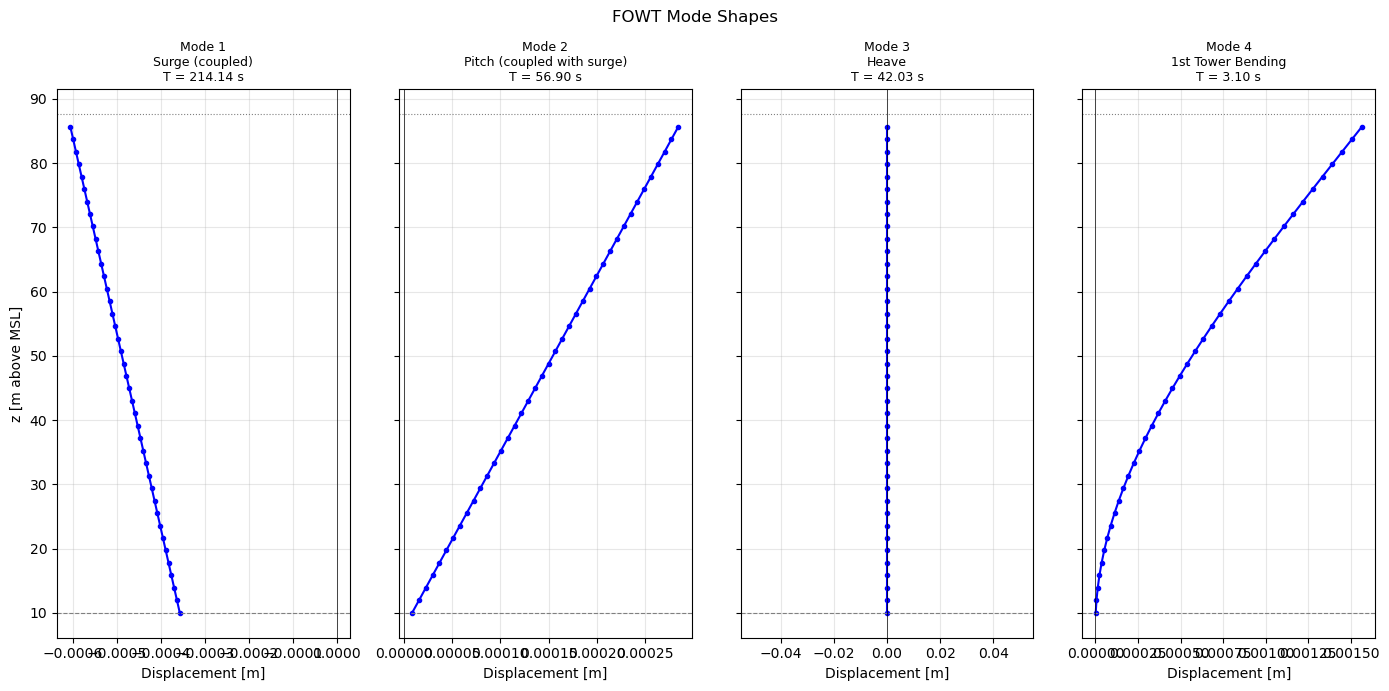

In [13]:
z_CoG = -89.9

# Plot mode shapes

n_modes = 4
mode_labels = ['Surge (coupled)', 'Pitch (coupled with surge)', 'Heave', '1st Tower Bending']
fig, axes = plt.subplots(1, n_modes, figsize=(14, 7), sharey=True)
for mode in range(n_modes):
    phi = eigenvectors[:, mode]

    x_f     = phi[0]   # floater surge
    z_f     = phi[1]   # floater heave
    theta_f = phi[2]   # floater pitch

    tower_disp = np.zeros(40)
    for k in range(40):
        w_elastic = phi[3 + 3*k + 1]           # elastic transverse DOF
        z_node    = nodes_z[k]
        # total horizontal displacement = rigid body translation + rigid body rotation + elastic bending
        tower_disp[k] = x_f + theta_f * (z_node - z_CoG) + w_elastic

    ax = axes[mode]
    ax.plot(tower_disp, nodes_z[:40], 'b-o', ms=3, lw=1.5)
    ax.axhline(z_base, color='gray', lw=0.8, ls='--', label='Tower base')
    ax.axhline(z_top,  color='gray', lw=0.8, ls=':',  label='Tower top')
    ax.axvline(0, color='k', lw=0.5)
    ax.set_title(f"Mode {mode+1}\n{mode_labels[mode]}\nT = {T_n[mode]:.2f} s", fontsize=9)
    ax.set_xlabel("Displacement [m]")
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel("z [m above MSL]")
plt.suptitle("FOWT Mode Shapes", fontsize=12)
plt.tight_layout()
plt.show()

In [14]:
labels = ['surge (x_f)', 'heave (z_f)', 'pitch (theta_f)']
for mode in range(4):
    phi = eigenvectors[:, mode]
    print(f"\nMode {mode+1} (T = {T_n[mode]:.2f} s):")
    for i, lab in enumerate(labels):
        print(f"  {lab}: {phi[i]:.6f}")


Mode 1 (T = 214.14 s):
  surge (x_f): -0.000028
  heave (z_f): 0.000000
  pitch (theta_f): -0.000003

Mode 2 (T = 56.90 s):
  surge (x_f): -0.000355
  heave (z_f): 0.000000
  pitch (theta_f): 0.000004

Mode 3 (T = 42.03 s):
  surge (x_f): 0.000000
  heave (z_f): 0.000259
  pitch (theta_f): 0.000000

Mode 4 (T = 3.10 s):
  surge (x_f): 0.000000
  heave (z_f): 0.000000
  pitch (theta_f): 0.000000


In [15]:
for mode in range(10):
    phi = eigenvectors[:, mode]
    print(f"Mode {mode+1} (T={T_n[mode]:.2f}s): x_f={phi[0]:.2e}, z_f={phi[1]:.2e}, theta_f={phi[2]:.2e}")

Mode 1 (T=214.14s): x_f=-2.78e-05, z_f=0.00e+00, theta_f=-3.29e-06
Mode 2 (T=56.90s): x_f=-3.55e-04, z_f=0.00e+00, theta_f=3.64e-06
Mode 3 (T=42.03s): x_f=0.00e+00, z_f=2.59e-04, theta_f=0.00e+00
Mode 4 (T=3.10s): x_f=0.00e+00, z_f=0.00e+00, theta_f=0.00e+00
Mode 5 (T=0.26s): x_f=0.00e+00, z_f=0.00e+00, theta_f=0.00e+00
Mode 6 (T=0.13s): x_f=0.00e+00, z_f=0.00e+00, theta_f=0.00e+00
Mode 7 (T=0.08s): x_f=0.00e+00, z_f=0.00e+00, theta_f=0.00e+00
Mode 8 (T=0.04s): x_f=0.00e+00, z_f=0.00e+00, theta_f=0.00e+00
Mode 9 (T=0.03s): x_f=0.00e+00, z_f=0.00e+00, theta_f=0.00e+00
Mode 10 (T=0.02s): x_f=0.00e+00, z_f=0.00e+00, theta_f=0.00e+00


In [16]:
mode = 1  # mode 2 (0-indexed)
phi = eigenvectors[:, mode]
print(f"Mode 2 (T={T_n[mode]:.2f}s) full eigenvector:")
for i, val in enumerate(phi):
    if abs(val) > 1e-8:  # only print non-negligible entries
        print(f"  DOF {i}: {val:.6e}")

Mode 2 (T=56.90s) full eigenvector:
  DOF 0: -3.554392e-04
  DOF 2: 3.644141e-06


In [17]:
print("Floater stiffness block (first 3x3):")
print(K_c [:3, :3])  

Floater stiffness block (first 3x3):
[[   88815.83              0.                0.        ]
 [       0.           333664.08878572        0.        ]
 [       0.                0.         73244697.3       ]]


In [18]:
mode = 2  # mode 3
phi = eigenvectors[:, mode]
print(f"Mode 3 full eigenvector:")
for i, val in enumerate(phi):
    if abs(val) > 1e-10:
        print(f"  DOF {i}: {val:.6e}")

Mode 3 full eigenvector:
  DOF 1: 2.587804e-04


In [19]:
print("Floater mass block (first 3x3):")
print(M_c[:3, :3])

Floater mass block (first 3x3):
[[1.49326600e+07 0.00000000e+00 7.46035694e+08]
 [0.00000000e+00 1.49326600e+07 0.00000000e+00]
 [7.46035694e+08 0.00000000e+00 7.87731165e+10]]


In [20]:
# Extract 2x2 surge-pitch subsystem (DOFs 0 and 2)
idx = [0, 2]
M_sp = M_c[np.ix_(idx, idx)]
K_sp = K_c[np.ix_(idx, idx)]

print("Surge-pitch mass block:")
print(M_sp)
print("\nSurge-pitch stiffness block:")
print(K_sp)

# Solve 2x2 eigenvalue problem
from scipy.linalg import eigh
vals, vecs = eigh(K_sp, M_sp)
freqs = np.sqrt(vals) / (2 * np.pi)
periods = 1 / freqs
print("\nExpected surge-pitch periods:", periods)

Surge-pitch mass block:
[[1.49326600e+07 7.46035694e+08]
 [7.46035694e+08 7.87731165e+10]]

Surge-pitch stiffness block:
[[   88815.83        0.  ]
 [       0.   73244697.3 ]]

Expected surge-pitch periods: [214.14491059  56.90068195]


In [21]:
#morison wave force on spar 

n_spar = 50 
z_spar = np.linspace(-draft, 0 ,n_spar)
dz = z_spar[1] - z_spar[0]

def wave_kinematics(z, t):
    cosh_ratio = np.cosh(k_wave * (z + +d_water)) / np.sinh(k_wave * d_water)
    u = omega_w * zeta_w * cosh_ratio * np.cos(omega_w * t)
    u_dot = -omega_w**2 * zeta_w * cosh_ratio * np.sin(omega_w * t)
    return u, u_dot

def morison_force_vector(t, n_dof_red):
    f = np.zeros(n_dof_red)
    F_morison = 0.0
    for z in z_spar:
        u, u_dot  = wave_kinematics(z, t)
        f_inertia = C_M * rho_w * np.pi/4 * D_above**2 * u_dot
        f_drag    = 0.5 * rho_w * C_D * D_above * u * np.abs(u)
        F_morison += (f_inertia + f_drag) * dz
    f[0] += F_morison
    return f   # wave + current drag only, no wind

f_test = morison_force_vector(0.0, n_red)
print(f"Morison force at t=0: {f_test[0]:.3e} N")
print(f"Wind thrust at top DOF: {f_test[3 + 3*(n_nodes-2)]:.3e} N")



Morison force at t=0: 1.620e+05 N
Wind thrust at top DOF: 0.000e+00 N


In [22]:
# Steady force (wind + current)
f_steady = np.zeros(n_red)

# Current drag on spar (depth-integrated, time-invariant)
F_current = 0.0
for z in z_spar:
    F_current += 0.5 * rho_w * C_D * D_above * U_c * abs(U_c) * dz
f_steady[0] += F_current

# Wind thrust at tower top
top_dof = 3 + 3*(n_nodes - 2)
f_steady[top_dof] += F_thrust

# Total force function for integrator
def F_total(t):
    return f_steady + morison_force_vector(t, n_red)

# Static equilibrium
u_static = np.linalg.solve(K_c, f_steady)
print(f"Current drag on spar:      {F_current:.3e} N")
print(f"Static surge equilibrium:  {u_static[0]:.3f} m")

Current drag on spar:      1.020e+05 N
Static surge equilibrium:  1.148 m


In [23]:
#rayleigh damping 

zeta_r = 0.02 
omega_1 = omega_n[0]
omega_4 = omega_n[3]

alpha_R = 2*zeta_r *omega_1 * omega_4 / (omega_1 + omega_4)
beta_R = 2*zeta_r / (omega_1 + omega_4)

C_c = alpha_R * M_c + beta_R * K_c

print(f"Rayleigh alpha  = {alpha_R:.6f}")
print(f"Rayleigh beta = {beta_R:.6g}")
print(f"C_c matrix assembled, size:  {C_c.shape}")


Rayleigh alpha  = 0.001157
Rayleigh beta = 0.0194654
C_c matrix assembled, size:  (123, 123)


In [24]:
from scipy.linalg import lu_factor, lu_solve

dt    = 0.5
t_end = 600.0
t_vec = np.arange(0, t_end + dt, dt)
n_t   = len(t_vec)

beta_nm  = 0.25
gamma_nm = 0.50

K_eff = K_c + (gamma_nm/(beta_nm*dt))*C_c + (1.0/(beta_nm*dt**2))*M_c
LU    = lu_factor(K_eff)

u = u_static.copy()
v = np.zeros(n_red)
a = np.linalg.solve(M_c, F_total(0.0) - C_c @ v - K_c @ u)

u_surge = np.zeros(n_t)
u_top   = np.zeros(n_t)
top_dof = 3 + 3*(n_nodes - 2)

print("Running integration...")
for i, t in enumerate(t_vec):
    u_surge[i] = u[0]
    u_top[i]   = u[top_dof]

    f      = F_total(t + dt)
    u_pred = u + dt*v + dt**2*(0.5 - beta_nm)*a
    v_pred = v + dt*(1 - gamma_nm)*a
    f_eff  = f - K_c @ u_pred - C_c @ v_pred
    a_new  = lu_solve(LU, f_eff)
    u_new  = u_pred + beta_nm*dt**2 * a_new
    v_new  = v_pred + gamma_nm*dt   * a_new
    u, v, a = u_new, v_new, a_new

print("Done")
print(f"Static equilibrium surge:  {u_static[0]:.3f} m")
print(f"Max floater surge:         {np.max(np.abs(u_surge)):.3f} m")
print(f"Mean floater surge:        {np.mean(u_surge):.3f} m")
print(f"Max tower top disp:        {np.max(np.abs(u_top)):.3f} m")

Running integration...
Done
Static equilibrium surge:  1.148 m
Max floater surge:         1.938 m
Mean floater surge:        1.067 m
Max tower top disp:        0.001 m


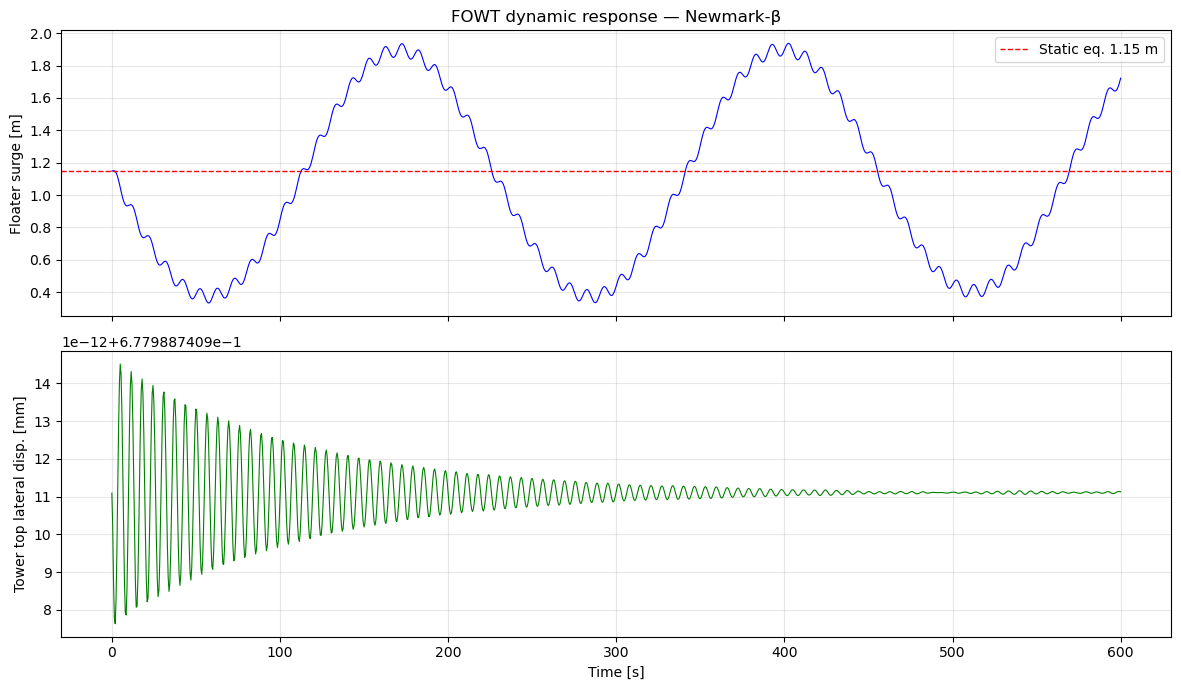

Summary
Static surge: 1.148 m
Mean surge: 1.067 m
Surge amplitude (std): 0.523 m
Max amplitude: 1.938 m
Min amplitude: 0.332 m
max tower top disp: 0.68 mm


In [25]:
fig, axes = plt.subplots(2,1, figsize = (12,7), sharex=True)

axes[0].plot(t_vec, u_surge, 'b', lw=0.8)
axes[0].axhline(u_static[0], color='r', ls='--', lw=1, label=f'Static eq. {u_static[0]:.2f} m')
axes[0].set_ylabel('Floater surge [m]')
axes[0].set_title('FOWT dynamic response — Newmark-β')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(t_vec, u_top*1000, 'g', lw=0.8)
axes[1].set_ylabel('Tower top lateral disp. [mm]')
axes[1].set_xlabel('Time [s]')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Summary")
print(f"Static surge: {u_static[0]:.3f} m")
print(f"Mean surge: {np.mean(u_surge):.3f} m")
print(f"Surge amplitude (std): {np.std(u_surge):.3f} m")
print(f"Max amplitude: {np.max(u_surge):.3f} m")
print(f"Min amplitude: {np.min(u_surge):.3f} m")
print(f"max tower top disp: {np.max(np.abs(u_top))*1000:.2f} mm")




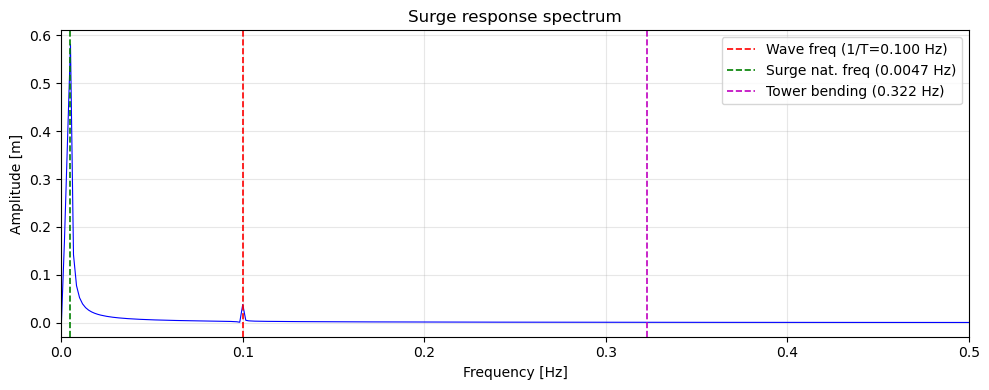

In [26]:
# Frequency spectrum of floater surge 
from numpy.fft import rfft, rfftfreq

# Remove mean before FFT
surge_ac = u_surge - np.mean(u_surge)
N        = len(surge_ac)
freqs_fft = rfftfreq(N, d=dt)
amp       = np.abs(rfft(surge_ac)) * 2 / N

plt.figure(figsize=(10, 4))
plt.plot(freqs_fft, amp, 'b', lw=0.8)
plt.axvline(1/T_wave, color='r', ls='--', lw=1.2, label=f'Wave freq (1/T={1/T_wave:.3f} Hz)')
plt.axvline(f_n[0],   color='g', ls='--', lw=1.2, label=f'Surge nat. freq ({f_n[0]:.4f} Hz)')
plt.axvline(f_n[3],   color='m', ls='--', lw=1.2, label=f'Tower bending ({f_n[3]:.3f} Hz)')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Amplitude [m]')
plt.title('Surge response spectrum')
plt.xlim([0, 0.5])
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

convergency study: run the model with different number of elements and the first tower bending frequency shiud converge

Convergence of 1st tower bending frequency:
n_elem     f [Hz]       T [s]
-----------------------------------
5          0.3223816308 3.1019137089
10         0.3223815455 3.1019145296
20         0.3223815401 3.1019145814
40         0.3223815406 3.1019145764


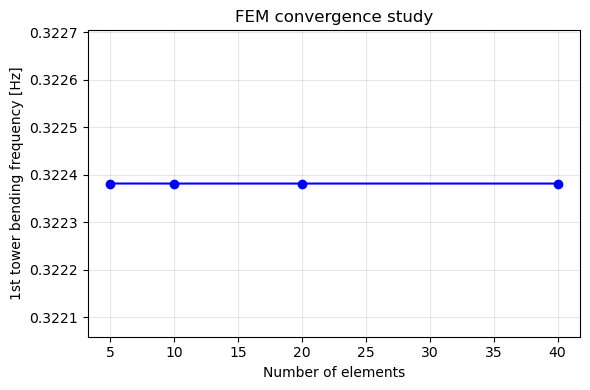

In [27]:
n_elem_list = [5, 10,20,40]

f1_list = []

for ne in n_elem_list:
    nn=ne+1
    le_c = L_tower /ne 
    NC = np.column_stack([np.zeros(nn), np.linspace(z_base, z_top, nn)])

    nd = 3 + 3*nn
    Mg_c = np.zeros((nd, nd))
    Kg_c = np.zeros((nd, nd))
    for ie in range(ne):
        Me_c, Ke_c = element_matrices(le_c)
        dofs_c = np.array([3+3*ie, 3+3*ie+1, 3+3*ie+2,
                           3+3*(ie+1), 3+3*(ie+1)+1, 3+3*(ie+1)+2])
        for ii in range(6):
            for jj in range(6):
                Mg_c[dofs_c[ii], dofs_c[jj]] += Me_c[ii, jj]
                Kg_c[dofs_c[ii], dofs_c[jj]] += Ke_c[ii, jj]

    Mg_c[0,0] += m_spar + C_a*rho_w*(m_spar/rho_w)
    Mg_c[1,1] += m_spar + C_a*rho_w*(m_spar/rho_w)
    Mg_c[2,2] += I_pitch
    Mg_c[3+3*ne, 3+3*ne] += m_RNA
    Mg_c[3+3*ne+1, 3+3*ne+1] += m_RNA

    # T_link
    Mc_c, Kc_c, _, nr_c = apply_kinematic_coupling(Mg_c, Kg_c, nd)
    Kc_c[0,0] += K_surge_moor
    Kc_c[1,1] += K_heave_hs + K_heave_moor
    Kc_c[2,2] += K_pitch_hs + K_pitch_moor       

    evals, _ = eigh(Kc_c, Mc_c)
    freqs = np.sqrt(np.abs(evals)) / (2*np.pi)
    f1_list.append(freqs[3])   # 1st tower bending = mode 4

print("Convergence of 1st tower bending frequency:")
print(f"{'n_elem':<10} {'f [Hz]':<12} {'T [s]'}")
print("-"*35)
for ne, f1 in zip(n_elem_list, f1_list):
    print(f"{ne:<10} {f1:<12.10f} {1/f1:.10f}")

plt.figure(figsize=(6,4))
plt.plot(n_elem_list, f1_list, 'bo-')
plt.xlabel('Number of elements')
plt.ylabel('1st tower bending frequency [Hz]')
plt.title('FEM convergence study')
plt.ylim([min(f1_list)*0.999, max(f1_list)*1.001])  # zoom in
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show() 

the 1st tower bending freqeuncy converges to 0.3224 Hz after just 5 elements. so 40 is more than sufficient. this is expected for a uniform beam 